In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_csv("ai_maintaindataset.csv")

In [7]:
# Renaming raw CSV column names to match project-friendly names

rename_map = {
    'Air temperature [K]': 'temperature',
    'Rotational speed [rpm]': 'vibration',
    'Torque [Nm]': 'pressure',
    'Machine failure': 'target'
}

# Apply column renaming on the dataframe
df = df.rename(columns=rename_map)

# Check updated column names
df.columns


Index(['UDI', 'Product ID', 'Type', 'temperature', 'Process temperature [K]',
       'vibration', 'pressure', 'Tool wear [min]', 'target', 'TWF', 'HDF',
       'PWF', 'OSF', 'RNF'],
      dtype='object')

In [8]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'temperature', 'Process temperature [K]',
       'vibration', 'pressure', 'Tool wear [min]', 'target', 'TWF', 'HDF',
       'PWF', 'OSF', 'RNF'],
      dtype='object')

In [9]:
# List of leakage and redundant columns
# TWF, HDF, PWF, OSF, RNF act like "cheat codes" for the model
# So we remove them to avoid data leakage

cols_to_drop = [
    'Process temperature [K]',
    'TWF',
    'HDF',
    'PWF',
    'OSF',
    'RNF'
]

# Dropping unnecessary columns
# errors='ignore' ensures the code does not crash
# if a column is already missing
df = df.drop(columns=cols_to_drop, errors='ignore')

# Check final columns used for modeling
print("Columns ready for modeling:")
print(df.columns)


Columns ready for modeling:
Index(['UDI', 'Product ID', 'Type', 'temperature', 'vibration', 'pressure',
       'Tool wear [min]', 'target'],
      dtype='object')


In [10]:
# 2. Add infer_objects here!
# This converts 'object' columns to 'numeric' if they contain numbers.
df = df.infer_objects(copy=False)

# 3. Now interpolation and other math tasks will be safe
df = df.interpolate(method='linear')

/tmp/ipython-input-4236429969.py:6: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='linear')


In [11]:
# 1. Identify numeric columns that need cleaning
numeric_cols = df.select_dtypes(include=[np.number]).columns

# 2. Linear Interpolation: Fills gaps by calculating the mid-point between two known values
# This is ideal for continuous sensor data like temperature or vibration
df[numeric_cols] = df[numeric_cols].interpolate(method='linear')

# 3. Back-filling (bfill): Fills any remaining NaNs at the very start of the dataset
# This ensures no missing values remain before the next engineering stage
df[numeric_cols] = df[numeric_cols].bfill()

# Verify that all missing values are gone
print(f"Missing values remaining: {df.isnull().sum().sum()}")

Missing values remaining: 0


In [12]:
# Creating features for the past 1, 4, and 8 hours
windows = [1, 4, 8]

for w in windows:
    # 1. Rolling mean (average temperature over last w hours)
    df[f'temp_mean_{w}h'] = df['temperature'].rolling(window=w).mean()

    # 2. Rolling standard deviation
    # This helps check how stable the vibration values are
    df[f'vib_std_{w}h'] = df['vibration'].rolling(window=w).std()

# Creating lag feature (previous time step value)
df['temp_lag_1'] = df['temperature'].shift(1)


In [15]:
df.head(10)

,UDI,Product ID,Type,temperature,vibration,pressure,Tool wear [min],target,temp_mean_1h,vib_std_1h,temp_mean_4h,vib_std_4h,temp_mean_8h,vib_std_8h,temp_lag_1
0,1,M14860,M,298.1,1551,42.8,0,0,298.1,NaN,NaN,NaN,NaN,NaN,NaN
1,2,L47181,L,298.2,1408,46.3,3,0,298.2,NaN,NaN,NaN,NaN,NaN,298.1
2,3,L47182,L,298.1,1498,49.4,5,0,298.1,NaN,NaN,NaN,NaN,NaN,298.2
3,4,L47183,L,298.2,1433,39.5,7,0,298.2,NaN,298.150,64.634872,NaN,NaN,298.1
4,5,L47184,L,298.2,1408,40.0,9,0,298.2,NaN,298.175,42.500000,NaN,NaN,298.2
5,6,M14865,M,298.1,1425,41.9,11,0,298.1,NaN,298.150,39.403892,NaN,NaN,298.2
6,7,L47186,L,298.1,1558,42.4,14,0,298.1,NaN,298.150,68.794380,NaN,NaN,298.1
7,8,L47187,L,298.1,1527,40.2,16,0,298.1,NaN,298.125,74.164232,298.1375,64.511350,298.1
8,9,M14868,M,298.3,1667,28.6,18,0,298.3,NaN,298.150,99.623876,298.1625,91.265703,298.1
9,10,M14869,M,298.5,1741,28.0,21,0,298.5,NaN,298.250,98.827712,298.2000,119.755033,298.3


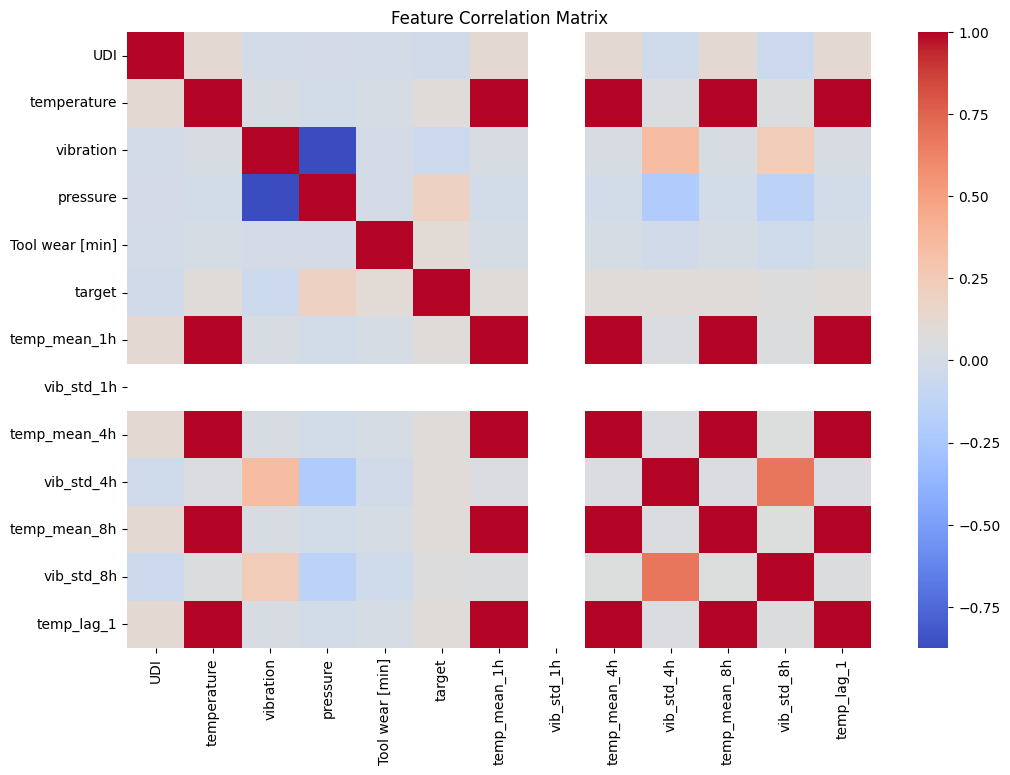

In [16]:
# Selecting only numeric columns to avoid errors
numeric_df = df.select_dtypes(include=[np.number])

# Calculating the correlation matrix
plt.figure(figsize=(12, 8))
correlation_matrix = numeric_df.corr()

# Plotting the correlation heatmap
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()


Task
Prepare the data for modeling by handling any remaining missing values in the DataFrame (especially those introduced by rolling and lag features) and split the data into training and testing sets, with 'target' as the target variable.

# **Prepare Data for Modeling**

In [17]:
# Drop rows that have any missing values
df.dropna(inplace=True)

# Verify if any missing values remain
total_missing = df.isnull().sum().sum()
print(f"Total missing values left in the dataset: {total_missing}")

# Show the new size of the dataset after dropping rows
print(f"Dataset shape after removing missing rows: {df.shape}")


Total missing values left in the dataset: 0
Dataset shape after removing missing rows: (0, 15)


### Prepare Data for Modeling (Retry NaN Handling)

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# --- Step 1: Load the dataset ---
df = pd.read_csv("ai_maintaindataset.csv")

# --- Step 2: Rename columns to match project-friendly names ---
rename_map = {
    'Air temperature [K]': 'temperature',
    'Rotational speed [rpm]': 'vibration',
    'Torque [Nm]': 'pressure',
    'Machine failure': 'target'
}
df = df.rename(columns=rename_map)

# --- Step 3: Drop leakage/redundant columns ---
cols_to_drop = ['Process temperature [K]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df = df.drop(columns=cols_to_drop, errors='ignore')

# --- Step 4: Clean numeric data ---
df = df.infer_objects(copy=False)  # Ensure proper dtypes
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].interpolate(method='linear')  # Fill numeric NaNs
df[numeric_cols] = df[numeric_cols].bfill()  # Backfill remaining numeric NaNs if any

# --- Step 5: Create rolling and lag features ---
windows = [1, 4, 8]
for w in windows:
    # Rolling mean for temperature
    df[f'temp_mean_{w}h'] = df['temperature'].rolling(window=w).mean()

    # Rolling std for vibration, only if window > 1
    if w > 1:
        df[f'vib_std_{w}h'] = df['vibration'].rolling(window=w).std()

# Lag feature for temperature (previous time step)
df['temp_lag_1'] = df['temperature'].shift(1)

# --- Step 6: Fill remaining NaNs caused by rolling/lag ---
df.ffill(inplace=True)
df.bfill(inplace=True)
print(f"Remaining missing values after ffill/bfill: {df.isnull().sum().sum()}")

# --- Step 7: One-hot encode categorical 'Type' column ---
df = pd.get_dummies(df, columns=['Type'], drop_first=True)
print(f"DataFrame columns after encoding 'Type': {df.columns.tolist()}")

# --- Step 8: Define features (X) and target (y) ---
X = df.drop(columns=['UDI', 'Product ID', 'target'])
y = df['target']

# --- Step 9: Split data into training and testing sets ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Step 10: Print shapes to verify ---
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


Remaining missing values after ffill/bfill: 0
DataFrame columns after encoding 'Type': ['UDI', 'Product ID', 'temperature', 'vibration', 'pressure', 'Tool wear [min]', 'target', 'temp_mean_1h', 'temp_mean_4h', 'vib_std_4h', 'temp_mean_8h', 'vib_std_8h', 'temp_lag_1', 'Type_L', 'Type_M']
X_train shape: (8000, 12)
X_test shape: (2000, 12)
y_train shape: (8000,)
y_test shape: (2000,)


## **Train and Evaluate Logistic Regression Baseline**

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, f1_score, roc_auc_score

# --- Step 1: Instantiate the Logistic Regression model ---
# Using class_weight='balanced' to handle class imbalance
# 'liblinear' solver works well for small datasets or with L1/L2 regularization
log_reg_model = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    solver='liblinear'
)

# --- Step 2: Train the model on training data ---
log_reg_model.fit(X_train, y_train)

# --- Step 3: Make predictions on the test set ---
y_pred_lr = log_reg_model.predict(X_test)

# --- Step 4: Get predicted probabilities for the positive class ---
y_pred_proba_lr = log_reg_model.predict_proba(X_test)[:, 1]

# --- Step 5: Evaluate model performance ---
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
auc = roc_auc_score(y_test, y_pred_proba_lr)

# --- Step 6: Print the results ---
print("Logistic Regression Baseline Performance:")
print(f"  Recall : {recall:.4f}")
print(f"  F1-score : {f1:.4f}")
print(f"  AUC : {auc:.4f}")


Logistic Regression Baseline Performance:
  Recall : 0.7541
  F1-score : 0.1836
  AUC : 0.8635


# **Train and Evaluate Random Forest Model**

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, f1_score, roc_auc_score

# 2. Instantiate a RandomForestClassifier object
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

# 3. Train the Random Forest model
rf_model.fit(X_train, y_train)

# 4. Predict the target variable for the test set
y_pred_rf = rf_model.predict(X_test)

# 5. Predict the probabilities of the positive class for the test set
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# 6. Calculate the Recall score
recall_rf = recall_score(y_test, y_pred_rf)

# 7. Calculate the F1-score
f1_rf = f1_score(y_test, y_pred_rf)

# 8. Calculate the AUC score
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

# 9. Print the calculated metrics
print(f"Random Forest Classifier Performance:")
print(f"  Recall: {recall_rf:.4f}")
print(f"  F1-score: {f1_rf:.4f}")
print(f"  AUC: {auc_rf:.4f}")

Random Forest Classifier Performance:
  Recall: 0.1803
  F1-score: 0.2821
  AUC: 0.9466


# **Train and Evaluate Initial XGBoost Modeln**

In [23]:
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, f1_score, roc_auc_score

# 2. Calculate scale_pos_weight for handling class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Calculated scale_pos_weight: {scale_pos_weight:.2f}")

# 3. Instantiate an XGBClassifier object
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_pos_weight)

# 4. Train the XGBoost model
xgb_model.fit(X_train, y_train)

# 5. Predict the target variable for the test set
y_pred_xgb = xgb_model.predict(X_test)

# 6. Predict the probabilities of the positive class for the test set
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# 7. Calculate the Recall score
recall_xgb = recall_score(y_test, y_pred_xgb)

# 8. Calculate the F1-score
f1_xgb = f1_score(y_test, y_pred_xgb)

# 9. Calculate the AUC score
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

# 10. Print the calculated metrics
print(f"\nXGBoost Classifier Performance (Initial Model):")
print(f"  Recall: {recall_xgb:.4f}")
print(f"  F1-score: {f1_xgb:.4f}")
print(f"  AUC: {auc_xgb:.4f}")

Calculated scale_pos_weight: 27.78


ValueError: feature_names must be string, and may not contain [, ] or <

The XGBoost model failed with a ValueError because feature names contained special characters like [ and ]. To resolve this, I will clean the column names of the X_train and X_test DataFrames by replacing invalid characters with underscores before training the model.

In [25]:
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, f1_score, roc_auc_score

# --- Step 1: Function to clean column names ---
# Remove special characters and replace spaces with underscores
def clean_col_names(df):
    new_cols = []
    for col in df.columns:
        clean_col = col.replace('[', '').replace(']', '') \
                       .replace('<', '').replace('>', '') \
                       .replace('(', '').replace(')', '') \
                       .replace(' ', '_')
        new_cols.append(clean_col)
    df.columns = new_cols
    return df

# Apply column cleaning to training and testing features
X_train = clean_col_names(X_train.copy())
X_test = clean_col_names(X_test.copy())

# --- Step 2: Calculate scale_pos_weight for class imbalance ---
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Calculated scale_pos_weight: {scale_pos_weight:.2f}")

# --- Step 3: Instantiate XGBoost Classifier ---
# use_label_encoder=False to avoid warnings
xgb_model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)

# --- Step 4: Train the model ---
xgb_model.fit(X_train, y_train)

# --- Step 5: Make predictions on the test set ---
y_pred_xgb = xgb_model.predict(X_test)

# --- Step 6: Predict probabilities for the positive class ---
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# --- Step 7: Evaluate performance ---
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

# --- Step 8: Print metrics ---
print("\nXGBoost Classifier Performance (Initial Model):")
print(f"  Recall : {recall_xgb:.4f}")
print(f"  F1-score : {f1_xgb:.4f}")
print(f"  AUC : {auc_xgb:.4f}")


Calculated scale_pos_weight: 27.78


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:50:44] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Classifier Performance (Initial Model):
  Recall : 0.5410
  F1-score : 0.5238
  AUC : 0.9527


# **Hyperparameter Tuning for XGBoost**

In [26]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from scipy.stats import uniform, randint

# --- Step 1: Calculate scale_pos_weight for class imbalance ---
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Calculated scale_pos_weight: {scale_pos_weight:.2f}")

# --- Step 2: Define parameter distributions for RandomizedSearchCV ---
# Using scipy.stats distributions for continuous or discrete random sampling
param_dist = {
    'learning_rate': uniform(loc=0.01, scale=0.29),  # 0.01 to 0.3
    'max_depth': randint(low=3, high=11),            # 3 to 10
    'subsample': uniform(loc=0.5, scale=0.5),       # 0.5 to 1.0
    'colsample_bytree': uniform(loc=0.5, scale=0.5),# 0.5 to 1.0
    'n_estimators': randint(low=100, high=1001)     # 100 to 1000
}

# --- Step 3: Clean column names for XGBoost ---
def clean_col_names(df):
    new_cols = []
    for col in df.columns:
        clean_col = col.replace('[', '').replace(']', '') \
                       .replace('<', '').replace('>', '') \
                       .replace('(', '').replace(')', '') \
                       .replace(' ', '_')
        new_cols.append(clean_col)
    df.columns = new_cols
    return df

X_train_cleaned = clean_col_names(X_train.copy())

# --- Step 4: Instantiate base XGBoost model ---
xgb_base_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    tree_method='hist'  # Faster for larger datasets
)

# --- Step 5: Set up RandomizedSearchCV ---
# Optimize for roc_auc due to class imbalance
random_search = RandomizedSearchCV(
    estimator=xgb_base_model,
    param_distributions=param_dist,
    n_iter=50,         # Number of random combinations to try
    scoring='roc_auc', # Optimize for AUC
    cv=5,              # 5-fold cross-validation
    verbose=1,
    random_state=42,
    n_jobs=-1          # Use all CPU cores
)

# --- Step 6: Fit RandomizedSearchCV on the training data ---
print("Starting RandomizedSearchCV...")
random_search.fit(X_train_cleaned, y_train)
print("RandomizedSearchCV completed.")

# --- Step 7: Print the best hyperparameters found ---
print("\nBest parameters found by RandomizedSearchCV:")
print(random_search.best_params_)


Calculated scale_pos_weight: 27.78
Starting RandomizedSearchCV...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
RandomizedSearchCV completed.

Best parameters found by RandomizedSearchCV:
{'colsample_bytree': np.float64(0.9303652916281717), 'learning_rate': np.float64(0.012016117854045303), 'max_depth': 10, 'n_estimators': 510, 'subsample': np.float64(0.7087055015743895)}


# **XGBoost model evaluation**

In [28]:
from sklearn.metrics import recall_score, f1_score, roc_auc_score

# 1. Retrieve the best parameters from RandomizedSearchCV
best_params = random_search.best_params_
print("Best parameters:", best_params)

# 2. Instantiate an XGBClassifier with the best parameters and scale_pos_weight
xgb_tuned_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    tree_method='hist',
    **best_params
)

# 3. Train the tuned XGBoost model
# Ensure X_train_cleaned is used, as it was used for tuning
xgb_tuned_model.fit(X_train_cleaned, y_train)

# 4. Predict the target variable for the test set
# Ensure X_test_cleaned is used for prediction
X_test_cleaned = clean_col_names(X_test.copy())
y_pred_xgb_tuned = xgb_tuned_model.predict(X_test_cleaned)

# 5. Predict the probabilities of the positive class for the test set
y_pred_proba_xgb_tuned = xgb_tuned_model.predict_proba(X_test_cleaned)[:, 1]

# 6. Calculate evaluation metrics
recall_xgb_tuned = recall_score(y_test, y_pred_xgb_tuned)
f1_xgb_tuned = f1_score(y_test, y_pred_xgb_tuned)
auc_xgb_tuned = roc_auc_score(y_test, y_pred_proba_xgb_tuned)

# 7. Print the calculated metrics
print(f"\nXGBoost Classifier Performance (Tuned Model):")
print(f"  Recall: {recall_xgb_tuned:.4f}")
print(f"  F1-score: {f1_xgb_tuned:.4f}")
print(f"  AUC: {auc_xgb_tuned:.4f}")

Best parameters: {'colsample_bytree': np.float64(0.9303652916281717), 'learning_rate': np.float64(0.012016117854045303), 'max_depth': 10, 'n_estimators': 510, 'subsample': np.float64(0.7087055015743895)}

XGBoost Classifier Performance (Tuned Model):
  Recall: 0.6721
  F1-score: 0.5942
  AUC: 0.9623


# **Evaluation Table and Comparison Graph**


Model Performance Evaluation Table:
| Model               |   Recall |   F1-score |      AUC |
|:--------------------|---------:|-----------:|---------:|
| Logistic Regression | 0.754098 |   0.183633 | 0.863509 |
| Random Forest       | 0.180328 |   0.282051 | 0.946559 |
| XGBoost (Initial)   | 0.540984 |   0.52381  | 0.95268  |
| XGBoost (Tuned)     | 0.672131 |   0.594203 | 0.962309 |


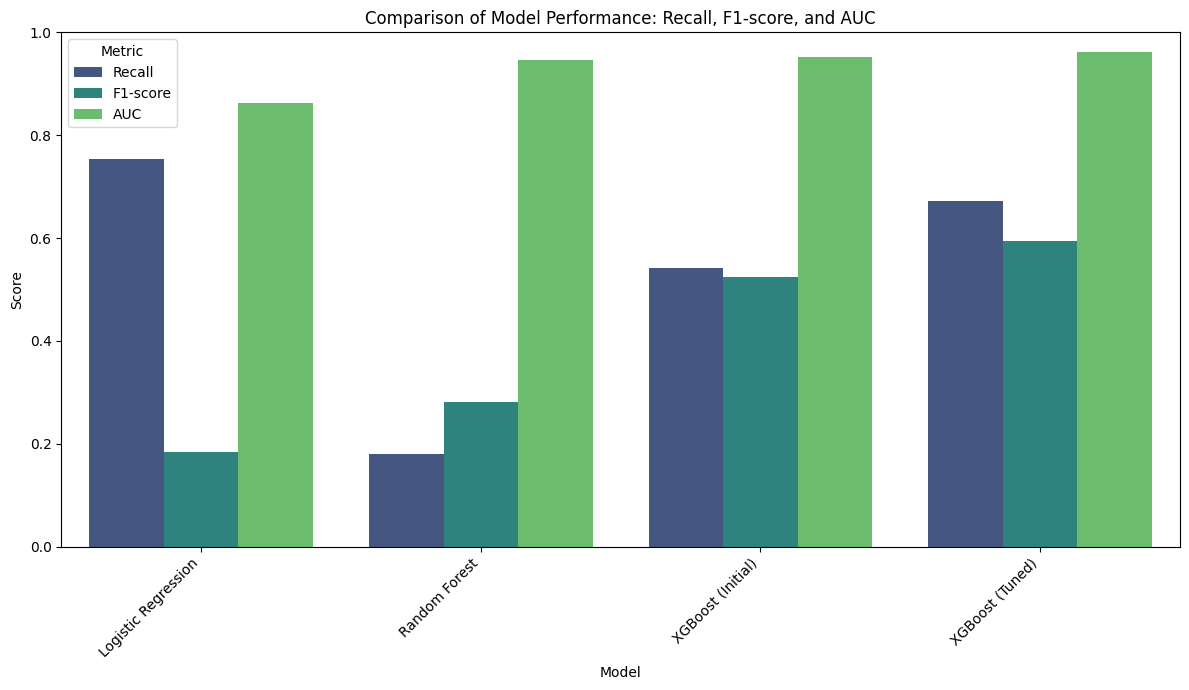

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Create a DataFrame to store performance metrics for each model
performance_data = {
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost (Initial)',
        'XGBoost (Tuned)'
    ],
    'Recall': [
        recall,          # From Logistic Regression
        recall_rf,       # From Random Forest
        recall_xgb,      # From initial XGBoost
        recall_xgb_tuned # From tuned XGBoost
    ],
    'F1-score': [
        f1,
        f1_rf,
        f1_xgb,
        f1_xgb_tuned
    ],
    'AUC': [
        auc,
        auc_rf,
        auc_xgb,
        auc_xgb_tuned
    ]
}

metrics_df = pd.DataFrame(performance_data)

# Step 2: Print the DataFrame in a clean table format
print("\nModel Performance Evaluation Table:")
print(metrics_df.to_markdown(index=False))

# Step 3: Reshape the DataFrame for plotting
# .melt() converts columns like 'Recall', 'F1-score', 'AUC' into a single 'Metric' column
metrics_melted = metrics_df.melt(id_vars=['Model'], var_name='Metric', value_name='Score')

# Step 4: Plot a grouped bar chart to compare metrics across models
plt.figure(figsize=(12, 7))
sns.barplot(
    x='Model',
    y='Score',
    hue='Metric',
    data=metrics_melted,
    palette='viridis'
)

# Step 5: Customize the plot for clarity
plt.title('Comparison of Model Performance: Recall, F1-score, and AUC')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1)  # Scores are between 0 and 1
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.legend(title='Metric')
plt.tight_layout()  # Adjust layout to avoid label overlap

# Step 6: Show the plot
plt.show()
